# Working with complicated dataset

Your name: Alvin Lee

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [ ]:
### Your code here . . .
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import urllib.request

blast_results = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

In [ ]:
with urllib.request.urlopen(blast_results) as response:
  for i in range(20):
    line = response.readline().decode('utf-8').strip()
    print(f"{i+1}: {line}")

1: # blastp,,,,,,,,,,,,,,,
2: # Iteration: 0,,,,,,,,,,,,,,,
3: # Query: YP_220550.1 NADH dehydrogenase subunit 1 (mitochondrion) [Mus musculus domesticus],,,,,,,,,,,,,,,
4: # RID: 9SW3UNUT015,,,,,,,,,,,,,,,
5: # Database: nr,,,,,,,,,,,,,,,
6: "# Fields: query acc.ver, subject acc.ver, % identity, alignment length, mismatches, gap opens, q. start, q. end, s. start, s. end, evalue, bit score, % positives, bonds, publications",,,,,,,,,,,,,,,
7: # 100 hits found,,,,,,,,,,,,,,,
8: YP_220550.1,NP_904328.1,100,318,0,0,1,318,1,318,0,629,100," 1,487 ",9,
9: YP_220550.1,AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100," 17,947 ",47,
10: YP_220550.1,YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100," 12,106 ",13,
11: YP_220550.1,ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69," 2,319 ",41,
12: YP_220550.1,AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100," 18,964 ",3,
13: YP_220550.1,AEN03421.1,99.686,318,1,0,1,318,1,318,0,626,99.69," 12,444 ",39,
14: YP_220550.1,6G2J_H,100,317,0,0,2,318,2,318,0,62

In [ ]:
blast_header = ["query acc.ver",
                "subject acc.ver",
                "% identity",
                "alignment length",
                "mismatches",
                "gap opens",
                "q. start",
                "q. end",
                "s. start",
                "s. end",
                "evalue",
                "bit score",
                "% positives",
                "bonds",
                "publications",
                "?"]


# Read blast_results
blast = (pd.read_csv(blast_results,
                    skiprows=6,
                    header=0,
                    names=blast_header))

# Drop last trivial column and "query acc.ver" column; then, set index to "subject acc.ver"
blast = blast.drop(columns="?")
blast = blast.drop(columns="query acc.ver")
blast = blast.set_index("subject acc.ver")

blast.head(5)

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3


### Question 2
What is the average number of publications?

In [ ]:
### Your code here . . .

# Drop rows with unknown number of publications
blast = blast.drop(blast[blast['publications'] == '-'].index)

# Convert column datatype from object to int64
blast.publications = blast.publications.astype('int64')

# Calculate the average number of publications
avg_publications = blast.publications.sum() / len(blast.publications)
print(avg_publications)

26.989690721649485


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [ ]:
### Your code here . . .

# Convert column datatype from object to int64
blast.bonds = blast.bonds.str.replace(",", "") # uncomment when necessary
blast.bonds = blast.bonds.astype('int64')

blast.bonds[blast.bonds > 15000]

,bonds
subject acc.ver,
AGK29621.1,17947
AHG32084.1,18964
6G2J_H,15663
YP_002791042.1,15830
AGK29634.1,17381
0806162F,17499
YP_009112408.1,16861
YP_001876469.1,16274
YP_009092269.1,16170


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

Text(0.5, 1.0, 'Correlation Between % Identity and % Positives')

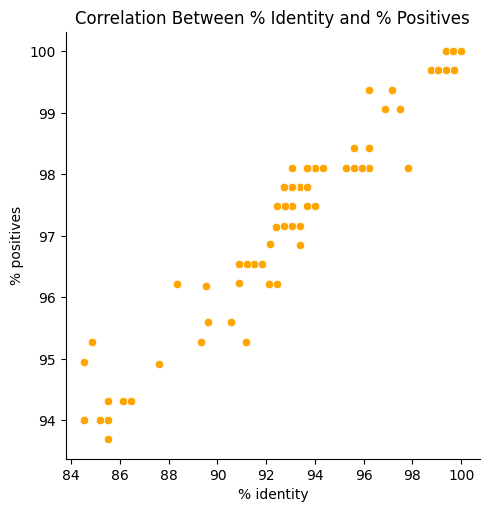

In [65]:
### Your code here . . .
percent_correlation = sns.relplot(
    data=blast,
    x="% identity",
    y="% positives",
    color="orange"
)

plt.title("Correlation Between % Identity and % Positives")

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [67]:
### Your code here . . .
# Read Protein source CSV file
protein_file = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"
protein = pd.read_csv(protein_file)

# Drop unwanted column "Unnamed: 0"
protein = protein.drop(columns="Unnamed: 0")

# Rename "Protein" to "subject acc.ver" and "Source" to "Protein source"
protein = protein.rename(columns={"Protein" : "subject acc.ver", "Source" : "Protein source"})

# Merge blast with protein only once; comment merge function after successful merge
# blast = blast.merge(right=protein, how="left", on="subject acc.ver") # uncomment when necessary
blast

,subject acc.ver,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein source
0,NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9,RefSeq
1,AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47,NaN
2,YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13,GenPept
3,ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41,NaN
4,AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,ABX45285.1,92.767,318,23,0,1,318,1,318,0,551,97.48,17348,6,NaN
93,ASP44815.1,93.375,317,21,0,1,317,1,317,0,551,96.85,7105,19,NaN
94,YP_009414156.1,84.543,317,49,0,1,317,1,317,0,551,94.01,18940,37,GenPept
95,YP_009414363.1,85.174,317,47,0,1,317,1,317,0,551,94.01,18762,5,GenPept
